# A2C Gridworld Taxi Navigation Policy

Tabular Q-learning fails as gridworld state spaces expand. Advantage Actor-Critic (A2C) upgrades agents to deep neural approximations, where policy predictions (actions probabilities) and state value predictions scale via parameterized multi-layer perceptrons. This notebook implements a neural Actor-Critic agent in PyTorch navigating a 5x5 Taxi Gridworld, trains it for 140 episodes, and plots loss curves.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Simulating simple 5x5 Gridworld environment
class GridworldTaxiEnv:
    def __init__(self):
        self.state = np.zeros(2) # [x, y] taxi coordinates
        self.reset()
        
    def reset(self):
        self.state = np.array([0, 0], dtype=np.float32)
        # Target passenger location is fixed at [4, 4]
        self.target = np.array([4, 4], dtype=np.float32)
        return self.state
        
    def step(self, action):
        # Actions: 0=Up, 1=Down, 2=Left, 3=Right
        move = np.zeros(2)
        if action == 0: move[1] = 1.0 # Up
        elif action == 1: move[1] = -1.0 # Down
        elif action == 2: move[0] = -1.0 # Left
        elif action == 3: move[0] = 1.0 # Right
        
        # Apply movements with grid bounds
        self.state = np.clip(self.state + move, 0.0, 4.0)
        
        # Calculate rewards: negative distance + passenger pick reward
        dist = np.linalg.norm(self.state - self.target)
        reward = -0.1
        done = False
        
        if dist < 0.1:
            reward = 10.0
            done = True
            
        return self.state, reward, done

env = GridworldTaxiEnv()



## Neural Actor-Critic Model Definition

We build the neural model predicting action probability distributions (4 categories) and state values in PyTorch.



In [2]:
class ActorCriticDiscrete(nn.Module):
    def __init__(self, state_dim=2, num_actions=4):
        super(ActorCriticDiscrete, self).__init__()
        self.base = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU()
        )
        self.actor = nn.Sequential(
            nn.Linear(32, num_actions),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Linear(32, 1)
        
    def forward(self, x):
        h = self.base(x)
        probs = self.actor(h)
        value = self.critic(h)
        return probs, value

model = ActorCriticDiscrete()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## A2C Navigation Training Loop

We train the discrete Actor-Critic agent for 140 episodes, optimizing policy gradient rewards and value loss.



In [3]:
epochs = 140
actor_losses = []
critic_losses = []

for ep in range(1, epochs + 1):
    state = env.reset()
    done = False
    
    ep_actor_loss = 0
    ep_critic_loss = 0
    steps = 0
    
    while not done and steps < 40:
        state_t = torch.FloatTensor(state)
        probs, value = model(state_t)
        
        # Categorical distribution sampling
        dist = Categorical(probs)
        action = dist.sample()
        
        # Environmental step
        next_state, reward, done = env.step(action.item())
        
        # Evaluate next state value
        next_value = model(torch.FloatTensor(next_state))[1].detach().item() if not done else 0.0
        td_target = reward + 0.95 * next_value
        advantage = td_target - value.item()
        
        # Actor Policy loss
        log_prob = dist.log_prob(action)
        actor_loss = -log_prob * advantage
        
        # Critic Value Loss
        critic_loss = nn.functional.mse_loss(value, torch.tensor([td_target], dtype=torch.float32))
        
        # Joint backward propagation
        loss = actor_loss + 0.5 * critic_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        ep_actor_loss += actor_loss.item()
        ep_critic_loss += critic_loss.item()
        
        state = next_state
        steps += 1
        
    actor_losses.append(ep_actor_loss / max(steps, 1))
    critic_losses.append(ep_critic_loss / max(steps, 1))
    
    if ep % 35 == 0:
        print(f"Episode {ep:3d}/{epochs} | Actor Loss: {actor_losses[-1]:.4f} | Critic Loss: {critic_losses[-1]:.4f}")



Episode  35/140 | Actor Loss: -0.0000 | Critic Loss: 0.0000
Episode  70/140 | Actor Loss: 0.0036 | Critic Loss: 0.0001
Episode 105/140 | Actor Loss: -0.0199 | Critic Loss: 0.0090
Episode 140/140 | Actor Loss: 0.0003 | Critic Loss: 0.0000


## Navigation Learning Progress Curves

We plot the actor policy gradient loss and value function critic MSE convergence trends in Matplotlib.



<cell>:19: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



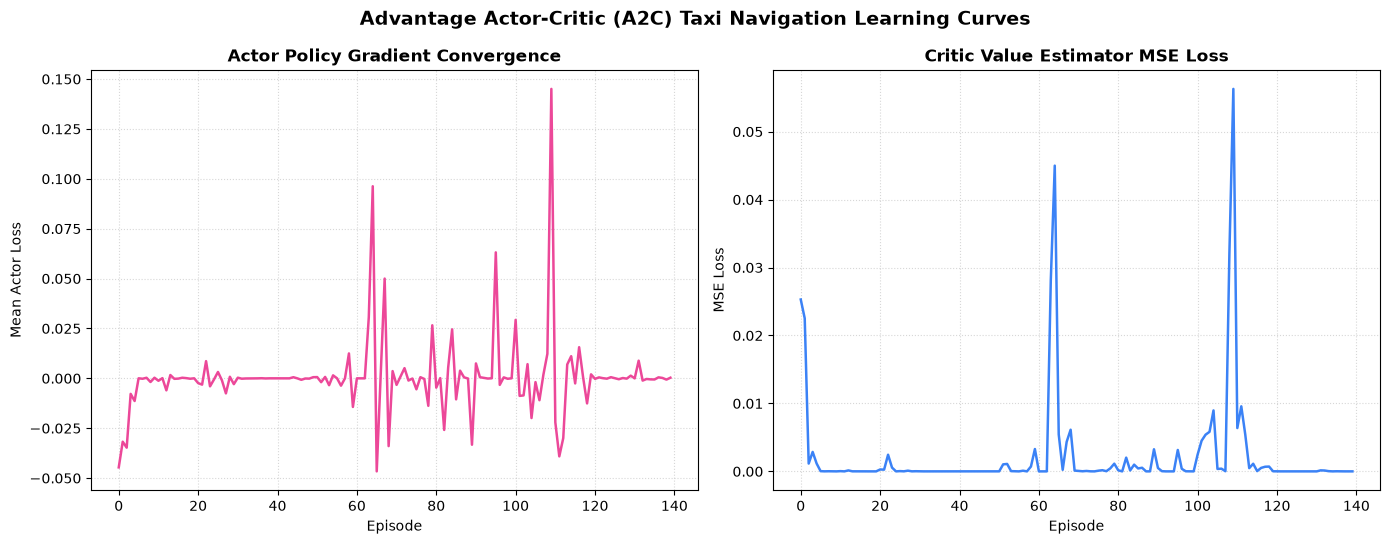

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Actor Loss
ax1.plot(actor_losses, color='#EC4899', linewidth=1.8, label='Actor Policy Loss')
ax1.set_title('Actor Policy Gradient Convergence', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Mean Actor Loss')
ax1.grid(True, linestyle=':', alpha=0.5)

# Critic Loss
ax2.plot(critic_losses, color='#3B82F6', linewidth=1.8, label='Critic Value Loss')
ax2.set_title('Critic Value Estimator MSE Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episode')
ax2.set_ylabel('MSE Loss')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Advantage Actor-Critic (A2C) Taxi Navigation Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
